### QAOA for MaxCut

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

In [3]:
# Define the Problem (MaxCut)

# Edges of our graph
edges = [(0, 1), (1, 2), (2, 0)]
n_qubits = 3

# Build the Cost Hamiltonian (Hc)
# For MaxCut, we want to maximize checking if neighbors have different bits (0 vs 1).
# The cost operator for an edge (i, j) is usually 0.5 * (I - ZiZj).
# To MINIMIZE energy in VQA, we map MaxCut to a Hamiltonian where the ground state is the answer.
# Hc = sum( Z_i * Z_j ) for all edges.
pauli_list = []
for i, j in edges:
    # "Z" on qubit i, "Z" on qubit j, "I" everywhere else
    # In Qiskit's SparsePauliOp string format, "ZZI" means Z on q2, Z on q1, I on q0.
    # We construct the string dynamically:
    p_string = ["I"] * n_qubits
    p_string[n_qubits - 1 - i] = "Z" # Qiskit qubit ordering is reversed (q0 is rightmost)
    p_string[n_qubits - 1 - j] = "Z"
    pauli_list.append("".join(p_string))

# This is our Cost Hamiltonian
# We minimize <H_c>. States with different spins (01 or 10) have lower energy (-1).
cost_hamiltonian = SparsePauliOp(pauli_list, coeffs=[1.0] * len(pauli_list))

print("Cost Hamiltonian Terms:", pauli_list)

Cost Hamiltonian Terms: ['IZZ', 'ZZI', 'ZIZ']


In [4]:
# This is our Cost Hamiltonian
def maxcut_hamiltonian(edges, n_qubits):
    pauli_list = []
    for i, j in edges:
        p_string = ["I"] * n_qubits
        p_string[n_qubits - 1 - i] = "Z" # Qiskit qubit ordering is reversed (q0 is rightmost)
        p_string[n_qubits - 1 - j] = "Z"
        pauli_list.append("".join(p_string))

    return SparsePauliOp(pauli_list, coeffs=[1.0] * len(pauli_list))

# small example
# Edges of our graph
edges = [(0, 1), (1, 2), (2, 0)]
n_qubits = 3
cost_h = maxcut_hamiltonian(edges, n_qubits)

In [5]:
# Create the standard QAOA circuit

def std_qaoa_circuit(p,edges,n_qubits):
    """
    Creates the QAOA circuit with depth p.
    Returns the circuit and the list of parameters (betas and gammas).
    """
    qc = QuantumCircuit(n_qubits)
    
    # QAOA Step 1: Initialize in superposition |+>
    qc.h(range(n_qubits))
    gammas = ParameterVector('Ɣ', p)
    betas = ParameterVector('β', p)
    
    for i in range(p):
        # Cost Layer 
        for edge in edges:
            u, v = edge
            # Rzz(angle) is exp(-i * angle/2 * Z Z). 
            qc.rzz(2 * gammas[i], u, v)
            
        # Mixer Layer 
        for q in range(n_qubits):
            qc.rx(2 * betas[i], q)
    return qc, list(gammas) + list(betas) #combine params List[Ɣ[0],...,Ɣ[p-1],β[0],...,β[p-1]]

In [6]:
# Optimization Loop over Depths ---
p = 1
estimator = StatevectorEstimator()
depths = list(range(1,p+1))

for p in depths:
    qc, params_list = std_qaoa_circuit(p,edges,n_qubits) 

    def cost_func(params):
        # Tuple: (circuit, observable, parameter_values)
        pub = (qc, cost_h, params)
        result = estimator.run([pub]).result()
        return result[0].data.evs

    # Random initialization
    init_point = []
    for _ in range(p):
        init_point.append(np.random.uniform(0, 2*np.pi)) # Gamma
    for _ in range(p):
        init_point.append(np.random.uniform(0, np.pi))   # Beta
        
    # Optimization
    res = minimize(cost_func, init_point, method='COBYLA', options={'maxiter': 200})
    
    print("\n--- Results ---")
    print(f"Optimal Parameters: {res.x}")
    print(f"Minimum Energy Found: {res.fun:.4f}")


--- Results ---
Optimal Parameters: [1.2631301 1.8786083]
Minimum Energy Found: -1.0000


In [7]:
# Verify the Result

# Let's look at the final state vector to see which bitstring is most probable
# We plug the optimal parameters back into the circuit
opt_params = res.x
# We need to bind these parameters to the circuit to see the state
bound_circuit = qc.assign_parameters(opt_params)

# We can use the Statevector class we used earlier
from qiskit.quantum_info import Statevector
final_state = Statevector.from_instruction(bound_circuit)
probs = final_state.probabilities_dict()

# Filter and print the top answers
print("\nTop Bitstrings (Most probable cuts):")
# Sort by probability
sorted_probs = sorted(probs.items(), key=lambda item: item[1], reverse=True)
for bitstring, prob in sorted_probs[:4]:
    print(f"State |{bitstring}>: {prob:.4f}")


Top Bitstrings (Most probable cuts):
State |001>: 0.1667
State |010>: 0.1667
State |011>: 0.1667
State |100>: 0.1667


### Larger example
Here we use the ```networkx``` package. And our favorite example, the House graph.

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()
edge_list = [
    (0, 1),
    (0, 2),
    (0, 4),
    (1, 2),
    (2, 3),
    (3, 4),
]
G.add_edges_from(edge_list)
print(f"The graph G has {G.number_of_nodes()} nodes, and {G.number_of_edges()} edges.")
print(f"Edges of the graph:{G.edges()}")
print(f"Nodes adjacent to [1]: {list(G.adj[1])}")

The graph G has 5 nodes, and 6 edges.
Edges of the graph:[(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (4, 3)]
Nodes adjacent to [1]: [0, 2]


In [10]:
edges = G.edges()
n_qubits = G.number_of_nodes()
cost_h = maxcut_hamiltonian(edges, n_qubits)

In [11]:
def get_cut_size(bitstring, edges):
    """Calculates number of cuts for a specific bitstring (e.g. '101')"""
    cut_value = 0
    # Reverse bitstring because Qiskit is Little-Endian (q0 is rightmost)
    for i, j in edges:
        if bitstring[i] != bitstring[j]:
            cut_value += 1
    return cut_value

def get_max_cut(n_qubits, edges):
    """Finds the maximum possible cut size by checking all 2^N states."""
    max_cut = 0
    for i in range(2**n_qubits):
        # Format integer i as binary string
        b_str = format(i, f'0{n_qubits}b') 
        val = get_cut_size(b_str, edges)
        if val > max_cut:
            max_cut = val
    return max_cut

# Calculate the denominator for our ratio
MAX_POSSIBLE_CUT = get_max_cut(n_qubits, edges)
print(f"Graph Max Cut (True Maximum): {MAX_POSSIBLE_CUT}")

Graph Max Cut (True Maximum): 5


In [13]:
# Optimization Loop over Depths ---
p = 10
estimator = StatevectorEstimator()
depths = list(range(1,p+1))
approx_ratios = []
print(f"\n{'Depth':<10} | {'Min Energy':<12} | {'Exp. Cut':<12} | {'Ratio':<10}")
print("-" * 55)

for p in depths:
    qc, params_list = std_qaoa_circuit(p,edges,n_qubits)

    def cost_func(params):
        # Tuple: (circuit, observable, parameter_values)
        pub = (qc, cost_h, params)
        result = estimator.run([pub]).result()
        return result[0].data.evs

    # Random initialization
    init_point = []
    for _ in range(p):
        init_point.append(np.random.uniform(0, 2*np.pi)) # Gamma
    for _ in range(p):
        init_point.append(np.random.uniform(0, np.pi))   # Beta
        
    # Optimization
    res = minimize(cost_func, init_point, method='COBYLA', options={'maxiter': 200})
    
    # --- Convert Energy to Cut Value ---
    # Relation: Cut = 0.5 * (Num_Edges - Energy)
    # Because H_c = sum(Z_i Z_j) and Cut_op = sum(0.5 * (I - Z_i Z_j))
    min_energy = res.fun
    expected_cut = 0.5 * (len(edges) - min_energy)
    
    ratio = expected_cut / MAX_POSSIBLE_CUT
    approx_ratios.append(ratio)
    
    print(f"{p:<10} | {min_energy:<12.4f} | {expected_cut:<12.4f} | {ratio:<10.4f}")
    # Compare probabilities of Top Bitstrings from start to finish
    if p == depths[0] or p == depths[-1]:
        opt_params = res.x
        # We need to bind these parameters to the circuit to see the state
        bound_circuit = qc.assign_parameters(opt_params)
        final_state = Statevector.from_instruction(bound_circuit)
        probs = final_state.probabilities_dict()
        # Filter and print the top answers
        print(f"\nTop Bitstrings (Most probable cuts) at Depth {p}:")
        # Sort by probability
        sorted_probs = sorted(probs.items(), key=lambda item: item[1], reverse=True)
        for bitstring, prob in sorted_probs[:4]:
            print(f"State |{bitstring}>: {prob:.4f}")


Depth      | Min Energy   | Exp. Cut     | Ratio     
-------------------------------------------------------
1          | -0.9975      | 3.4987       | 0.6997    

Top Bitstrings (Most probable cuts) at Depth 1:
State |01010>: 0.0968
State |10101>: 0.0968
State |01101>: 0.0968
State |10010>: 0.0968
2          | -2.3294      | 4.1647       | 0.8329    
3          | -3.3618      | 4.6809       | 0.9362    
4          | -3.5996      | 4.7998       | 0.9600    
5          | -3.2894      | 4.6447       | 0.9289    
6          | -3.1485      | 4.5743       | 0.9149    
7          | -3.5848      | 4.7924       | 0.9585    
8          | -3.5400      | 4.7700       | 0.9540    
9          | -3.8237      | 4.9119       | 0.9824    
10         | -3.5126      | 4.7563       | 0.9513    

Top Bitstrings (Most probable cuts) at Depth 10:
State |01001>: 0.2091
State |10110>: 0.2091
State |01011>: 0.2091
State |10100>: 0.2091


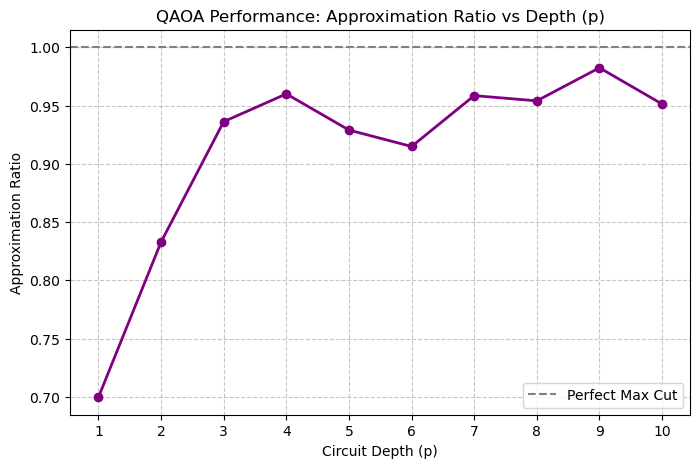

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(depths, approx_ratios, 'o-', linewidth=2, color='purple')
plt.title('QAOA Performance: Approximation Ratio vs Depth (p)')
plt.xlabel('Circuit Depth (p)')
plt.ylabel('Approximation Ratio')
plt.axhline(1.0, color='gray', linestyle='--', label='Perfect Max Cut')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(depths)
plt.show()